In [10]:
from google.colab import drive
drive.mount('/drive')

import os
import cv2
import joblib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =========================
# PATHS
# =========================

BASE = '/drive/MyDrive/AI-Image-Analysis-Project'

DATASETS = f'{BASE}/bmi_prediction/datasets'

RAW = f'{DATASETS}/Visual BMI/bodyface_1to17'

ANNOT = f'{DATASETS}/visual_bmi_annotations.csv'

PROCESSED = f'{DATASETS}/processed'

MODELS = f'{BASE}/bmi_prediction/saved_models'

RESULTS = f'{BASE}/bmi_prediction/results'

os.makedirs(PROCESSED, exist_ok=True)

print("✅ Setup complete")
print(os.path.exists(RAW))
print(os.path.exists(ANNOT))

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
✅ Setup complete
True
True


In [12]:
df = pd.read_csv(ANNOT)

print(df.shape)
print(df.columns)

def fix_path(kaggle_path):

    parts = kaggle_path.split('bodyface_1to17/')

    if len(parts) != 2:
        return None

    return os.path.join(RAW, parts[1])

# Create local paths
df['local_path'] = df['image_path'].apply(fix_path)

# Remove invalid rows only
clean_df = df[df['local_path'].notnull()].copy()

# Keep required columns
clean_df = clean_df[
    [
        'local_path',
        'person_id',
        'BMI',
        'weight_lb',
        'height_in',
        'is_female'
    ]
]

clean_df.columns = [
    'img_path',
    'person_id',
    'bmi',
    'weight_lb',
    'height_in',
    'is_female'
]

clean_df = clean_df.reset_index(drop=True)

print(f"\nClean samples: {len(clean_df)}")

clean_df.head()

(5897, 7)
Index(['image_path', 'person_id', 'image_id', 'weight_lb', 'height_in',
       'is_female', 'BMI'],
      dtype='object')

Clean samples: 5897


,img_path,person_id,bmi,weight_lb,height_in,is_female
0,/drive/MyDrive/AI-Image-Analysis-Project/bmi_p...,2a42h0,31.38,225.0,71.0,False
1,/drive/MyDrive/AI-Image-Analysis-Project/bmi_p...,2a42h0,30.12,216.0,71.0,False
2,/drive/MyDrive/AI-Image-Analysis-Project/bmi_p...,2xraoq,34.38,213.0,66.0,True
3,/drive/MyDrive/AI-Image-Analysis-Project/bmi_p...,2xraoq,34.38,213.0,66.0,True
4,/drive/MyDrive/AI-Image-Analysis-Project/bmi_p...,3xptz5,26.15,167.0,67.0,False


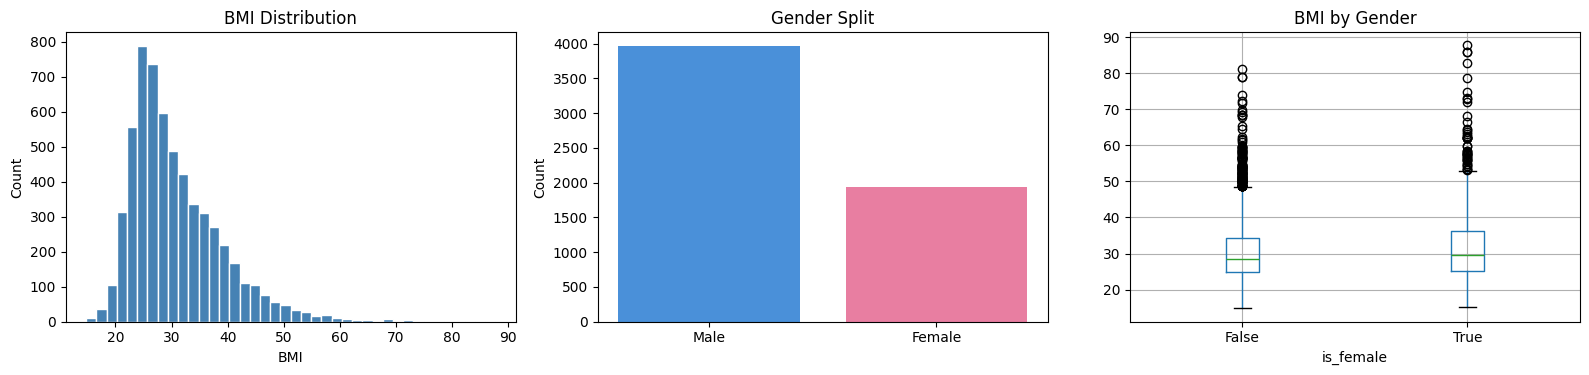

✅ EDA complete


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# BMI Distribution
axes[0].hist(
    clean_df['bmi'],
    bins=40,
    color='steelblue',
    edgecolor='white'
)

axes[0].set_title('BMI Distribution')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Count')

# Gender Split
male_count = (clean_df['is_female'] == False).sum()
female_count = (clean_df['is_female'] == True).sum()

axes[1].bar(
    ['Male', 'Female'],
    [male_count, female_count],
    color=['#4A90D9', '#E87EA1']
)

axes[1].set_title('Gender Split')
axes[1].set_ylabel('Count')

# BMI by Gender
clean_df.boxplot(
    column='bmi',
    by='is_female',
    ax=axes[2]
)

axes[2].set_title('BMI by Gender')
axes[2].set_xlabel('is_female')

plt.suptitle('')

plt.tight_layout()

plt.savefig(
    f'{RESULTS}/eda_overview.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ EDA complete")

In [14]:
unique_persons = clean_df['person_id'].unique()

train_persons, test_persons = train_test_split(
    unique_persons,
    test_size=0.2,
    random_state=42
)

train_df = clean_df[
    clean_df['person_id'].isin(train_persons)
].reset_index(drop=True)

test_df = clean_df[
    clean_df['person_id'].isin(test_persons)
].reset_index(drop=True)

print(f"Train samples: {len(train_df)}")
print(f"Test samples : {len(test_df)}")

Train samples: 4717
Test samples : 1180


In [17]:
def extract_enhanced_features(
    img_path,
    weight_lb,
    height_in,
    is_female
):

    img = cv2.imread(img_path)

    if img is None:
        return None

    img = cv2.resize(img, (128, 128))

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # HOG
    hog_feats = hog(
        img_gray,
        orientations=8,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        visualize=False
    )

    # Color
    color_feats = img_rgb.mean(axis=(0, 1))

    # Statistics
    stat_feats = np.array([
        img_gray.mean(),
        img_gray.std(),
        img_gray.min(),
        img_gray.max()
    ])

    # Tabular
    tabular_feats = np.array([
        weight_lb / 400.0,
        height_in / 100.0,
        float(is_female)
    ])

    # Combine
    features = np.concatenate([
        hog_feats,
        color_feats,
        stat_feats,
        tabular_feats
    ])

    return features

In [18]:
print("Extracting train features...")

X_train = []
y_train = []

for _, row in tqdm(train_df.iterrows(), total=len(train_df)):

    feats = extract_enhanced_features(
        row['img_path'],
        row['weight_lb'],
        row['height_in'],
        row['is_female']
    )

    if feats is not None:
        X_train.append(feats)
        y_train.append(row['bmi'])

print("\nExtracting test features...")

X_test = []
y_test = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):

    feats = extract_enhanced_features(
        row['img_path'],
        row['weight_lb'],
        row['height_in'],
        row['is_female']
    )

    if feats is not None:
        X_test.append(feats)
        y_test.append(row['bmi'])

X_train = np.array(X_train)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

print("\n✅ Feature extraction complete")

print(X_train.shape)
print(X_test.shape)

Extracting train features...


100%|██████████| 4717/4717 [1:03:07<00:00,  1.25it/s]



Extracting test features...


100%|██████████| 1180/1180 [15:52<00:00,  1.24it/s]


✅ Feature extraction complete
(4717, 1578)
(1180, 1578)


In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

np.save(f'{PROCESSED}/X_train.npy', X_train_scaled)

np.save(f'{PROCESSED}/X_test.npy', X_test_scaled)

np.save(f'{PROCESSED}/y_train.npy', y_train)

np.save(f'{PROCESSED}/y_test.npy', y_test)

joblib.dump(
    scaler,
    f'{MODELS}/scaler.pkl'
)

print("✅ Saved successfully")

✅ Saved successfully
